
ЯК КОРИСТУВАТИСЯ ПРОГРАМОЮ:
1. Слайдери змінюють параметри сигналу та шуму.
2. При зміні гармоніки малюнок шуму не змінюється.
3. Чекбокс 'Шум' вмикає/вимикає його відображення.
4. Кнопка 'Скинути' повертає початкові значення.



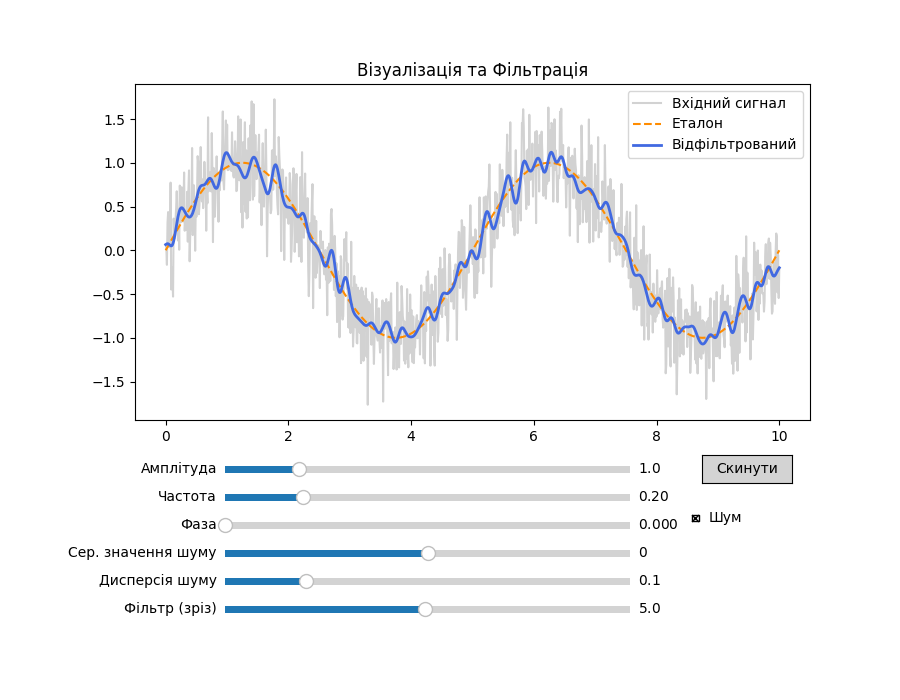

In [8]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import butter, filtfilt

def harmonic_with_noise(t, amplitude, frequency, phase, noise_mean, noise_covariance, show_noise):
    harmonic = amplitude * np.sin(2 * np.pi * frequency * t + phase)
    noise = np.random.normal(noise_mean, np.sqrt(max(0, noise_covariance)), len(t))
    if show_noise:
        return harmonic + noise
    else:
        return harmonic

t = np.linspace(0, 10, 1000)
init_amp = 1.0
init_freq = 0.2
init_phase = 0.0
init_mean = 0.0
init_cov = 0.1
init_cutoff = 5.0

current_noise = np.random.normal(init_mean, np.sqrt(init_cov), len(t))
noise_state = {'mean': init_mean, 'cov': init_cov}

def apply_filter(data, cutoff):
    if cutoff <= 0: return data
    fs = 100
    nyq = 0.5 * fs
    normal_cutoff = min(cutoff / nyq, 0.99)
    b, a = butter(4, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

fig, ax = plt.subplots(figsize=(9, 7))
plt.subplots_adjust(bottom=0.4, left=0.15)

y_pure = init_amp * np.sin(2 * np.pi * init_freq * t + init_phase)
y_noisy = y_pure + current_noise

line_noisy, = ax.plot(t, y_noisy, color='silver', alpha=0.7, label='Вхідний сигнал')
line_clean, = ax.plot(t, y_pure, color='darkorange', linestyle='--', label='Еталон')
line_filt, = ax.plot(t, apply_filter(y_noisy, init_cutoff), color='royalblue', linewidth=2, label='Відфільтрований')

ax.set_title("Візуалізація та Фільтрація")
ax.legend(loc='upper right')

ax_amp    = plt.axes([0.25, 0.32, 0.45, 0.02])
ax_freq   = plt.axes([0.25, 0.28, 0.45, 0.02])
ax_phase  = plt.axes([0.25, 0.24, 0.45, 0.02])
ax_mean   = plt.axes([0.25, 0.20, 0.45, 0.02])
ax_cov    = plt.axes([0.25, 0.16, 0.45, 0.02])
ax_cutoff = plt.axes([0.25, 0.12, 0.45, 0.02])

s_amp    = Slider(ax_amp, 'Амплітуда', 0.1, 5.0, valinit=init_amp)
s_freq   = Slider(ax_freq, 'Частота', 0.01, 1.0, valinit=init_freq)
s_phase  = Slider(ax_phase, 'Фаза', 0.0, 2*np.pi, valinit=init_phase)
s_mean = Slider(ax_mean, 'Сер. значення шуму', -1.0, 1.0, valinit=init_mean)
s_cov    = Slider(ax_cov, 'Дисперсія шуму', 0.0, 0.5, valinit=init_cov)
s_cutoff = Slider(ax_cutoff, 'Фільтр (зріз)', 0.1, 10.0, valinit=init_cutoff)

ax_check = plt.axes([0.75, 0.24, 0.15, 0.04], frameon=False)
check = CheckButtons(ax_check, ['Шум'], [True])

ax_reset = plt.axes([0.78, 0.31, 0.1, 0.04])
btn_reset = Button(ax_reset, 'Скинути', color='lightgray')

def update(val):
    global current_noise
    
    if s_mean.val != noise_state['mean'] or s_cov.val != noise_state['cov']:
        current_noise = np.random.normal(s_mean.val, np.sqrt(max(0, s_cov.val)), len(t))
        noise_state['mean'] = s_mean.val
        noise_state['cov'] = s_cov.val
    
    y_pure_upd = s_amp.val * np.sin(2 * np.pi * s_freq.val * t + s_phase.val)
    y_noisy_upd = y_pure_upd + current_noise
    
    show = check.get_status()[0]
    line_noisy.set_ydata(y_noisy_upd if show else y_pure_upd)
    line_clean.set_ydata(y_pure_upd)
    line_filt.set_ydata(apply_filter(y_noisy_upd, s_cutoff.val))
    
    fig.canvas.draw_idle()

s_amp.on_changed(update)
s_freq.on_changed(update)
s_phase.on_changed(update)
s_mean.on_changed(update)
s_cov.on_changed(update)
s_cutoff.on_changed(update)
check.on_clicked(update)

def reset_fields(event):
    s_amp.reset()
    s_freq.reset()
    s_phase.reset()
    s_mean.reset()
    s_cov.reset()
    s_cutoff.reset()
btn_reset.on_clicked(reset_fields)

print("""
ЯК КОРИСТУВАТИСЯ ПРОГРАМОЮ:
1. Слайдери змінюють параметри сигналу та шуму.
2. При зміні гармоніки малюнок шуму не змінюється.
3. Чекбокс 'Шум' вмикає/вимикає його відображення.
4. Кнопка 'Скинути' повертає початкові значення.
""")

plt.show()